In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("goodreads_3500_master.csv")

In [3]:
df.head()

,Title,Author,Rating,Rating_Count,Review_Count,Price_INR,Pub_Date,Page_Count,Genres,ISBN,Description
0,Harry Potter and the Deathly Hallows,J.K. Rowling,4.62,4167736,101662,NaN,21-Jul-07,784,"Fantasy, Fiction, Young Adult, Harry Potter, M...",9.780550e+12,"It's no longer safe for Harry at Hogwarts, so ..."
1,The Hunger Games,Suzanne Collins,4.35,10088121,269185,NaN,14-Sep-08,374,"Young Adult, Dystopia, Fiction, Fantasy, Scien...",9.780440e+12,Winning means fame and fortune. Losing means c...
2,The Kite Runner,Khaled Hosseini,4.36,3548170,116730,NaN,29-May-03,371,"Fiction, Historical Fiction, Classics, Contemp...",9.781590e+12,1970s Twelve-year-old Amir is desperate to win...
3,The Book Thief,Markus Zusak,4.39,2927965,163552,NaN,1-Sep-05,592,"Historical Fiction, Fiction, Young Adult, Clas...",NaN,Librarian's note: An alternate cover edition c...
4,Harry Potter and the Half-Blood Prince,J.K. Rowling,4.58,3714108,72614,NaN,16-Jul-05,672,"Fantasy, Fiction, Young Adult, Harry Potter, M...",NaN,The war against Voldemort is not going well: e...


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4026 entries, 0 to 4025
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         4026 non-null   str    
 1   Author        4020 non-null   str    
 2   Rating        4026 non-null   float64
 3   Rating_Count  4026 non-null   int64  
 4   Review_Count  4026 non-null   int64  
 5   Price_INR     0 non-null      float64
 6   Pub_Date      4020 non-null   str    
 7   Page_Count    4026 non-null   int64  
 8   Genres        3677 non-null   str    
 9   ISBN          3526 non-null   float64
 10  Description   4015 non-null   str    
dtypes: float64(3), int64(3), str(5)
memory usage: 346.1 KB


In [5]:
df.describe()

,Rating,Rating_Count,Review_Count,Price_INR,Page_Count,ISBN
count,4026.000000,4.026000e+03,4026.000000,0.0,4026.000000,3.526000e+03
mean,4.024935,1.374295e+05,9232.255092,NaN,365.661451,9.781103e+12
std,0.360115,4.309812e+05,25261.061854,NaN,200.192126,1.505759e+09
min,0.000000,0.000000e+00,0.000000,NaN,0.000000,9.780000e+12
25%,3.830000,1.282500e+03,133.000000,NaN,266.000000,9.780380e+12
50%,4.030000,2.264100e+04,1645.500000,NaN,340.000000,9.780740e+12
75%,4.220000,9.847000e+04,6832.000000,NaN,433.000000,9.781460e+12
max,5.000000,1.008812e+07,402607.000000,NaN,4081.000000,9.790000e+12


In [6]:
print(df["Price_INR"].notnull().sum())
print((df["Price_INR"].isnull().sum() / len(df)) * 100)

0
100.0


In [7]:
df.drop(columns=["Price_INR"], inplace=True) # remove price_inr

- The `Price_INR` column contained 100% missing values and no reliable pricing data could be collected from the explored sources.
-  Multiple sources-> including Goodreads, Google Books API, and Open Library API, were explored for pricing information.
 Therefore, the column was removed during EDA.


In [8]:
df.duplicated().sum()

np.int64(5)

In [9]:
df.duplicated(subset=["Title", "Author"]).sum()

np.int64(5)

In [10]:
duplicates = df[df.duplicated(subset=["Title", "Author"], keep=False)]

duplicates[["Title", "Author"]]

,Title,Author
2331,"Sorry, we couldn’t find the page you were look...",NaN
3157,"Sorry, we couldn’t find the page you were look...",NaN
3208,"Sorry, we couldn’t find the page you were look...",NaN
3579,"Sorry, we couldn’t find the page you were look...",NaN
3730,"Sorry, we couldn’t find the page you were look...",NaN
3992,"Sorry, we couldn’t find the page you were look...",NaN


In [11]:
df.loc[[2331,3157,3208,3579,3730,3992]]

,Title,Author,Rating,Rating_Count,Review_Count,Pub_Date,Page_Count,Genres,ISBN,Description
2331,"Sorry, we couldn’t find the page you were look...",NaN,0.0,0,0,NaN,0,NaN,NaN,NaN
3157,"Sorry, we couldn’t find the page you were look...",NaN,0.0,0,0,NaN,0,NaN,NaN,NaN
3208,"Sorry, we couldn’t find the page you were look...",NaN,0.0,0,0,NaN,0,NaN,NaN,NaN
3579,"Sorry, we couldn’t find the page you were look...",NaN,0.0,0,0,NaN,0,NaN,NaN,NaN
3730,"Sorry, we couldn’t find the page you were look...",NaN,0.0,0,0,NaN,0,NaN,NaN,NaN
3992,"Sorry, we couldn’t find the page you were look...",NaN,0.0,0,0,NaN,0,NaN,NaN,NaN


In [12]:
df.drop_duplicates(subset=["Title", "Author"], inplace=True)

In [13]:
df.duplicated(subset=["Title", "Author"]).sum()

np.int64(0)

Duplicate book entries identified during EDA were removed from the dataset based on repeated title and author combinations.


In [14]:
df.isnull().sum()

Title             0
Author            1
Rating            0
Rating_Count      0
Review_Count      0
Pub_Date          1
Page_Count        0
Genres          344
ISBN            495
Description       6
dtype: int64

Encoding missing values

In [15]:
df[df["Author"].isnull()]

,Title,Author,Rating,Rating_Count,Review_Count,Pub_Date,Page_Count,Genres,ISBN,Description
2331,"Sorry, we couldn’t find the page you were look...",NaN,0.0,0,0,NaN,0,NaN,NaN,NaN


In [16]:
df = df[~df["Title"].str.contains("Sorry, we couldn’t find the page", na=False)]

In [17]:
# No description available-> for missing descritpion rows
df["Description"] = df["Description"].fillna("No description available")

In [18]:
# Unknown for missing values in genre
df["Genres"] = df["Genres"].fillna("Unknown")

In [19]:
df.isnull().sum()

Title             0
Author            0
Rating            0
Rating_Count      0
Review_Count      0
Pub_Date          0
Page_Count        0
Genres            0
ISBN            494
Description       0
dtype: int64

- Invalid rows generated from Goodreads error pages were removed from the dataset. 
- Missing values in the Description column were replaced with "No description available", while missing values in the Genres column were filled with "Unknown" to preserve dataset consistency.

In [20]:
df.dtypes

Title               str
Author              str
Rating          float64
Rating_Count      int64
Review_Count      int64
Pub_Date            str
Page_Count        int64
Genres              str
ISBN            float64
Description         str
dtype: object

In [21]:
# covnerting pub_date str into datetime
df["Pub_Date"] = pd.to_datetime(df["Pub_Date"], errors="coerce")

C:\Users\Aifa\AppData\Local\Temp\ipykernel_7844\4062060423.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Pub_Date"] = pd.to_datetime(df["Pub_Date"], errors="coerce")


In [22]:
df["Pub_Date"].isnull().sum()
# small number of publication dates could not be parsed due to inconsistent scraped formats 
#  and were automatically converted to missing datetime values (`NaT`).

np.int64(15)

### ANALYSIS

<Axes: xlabel='Rating_Count', ylabel='Count'>

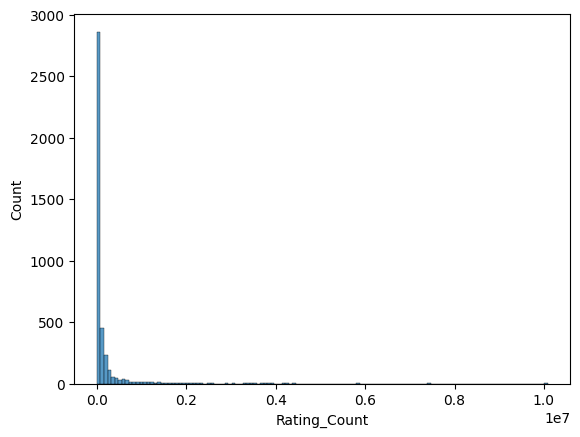

In [23]:
sns.histplot(df["Rating_Count"])

In [24]:
df["Log_Rating_Count"] = np.log1p(df["Rating_Count"])

<Axes: xlabel='Log_Rating_Count', ylabel='Count'>

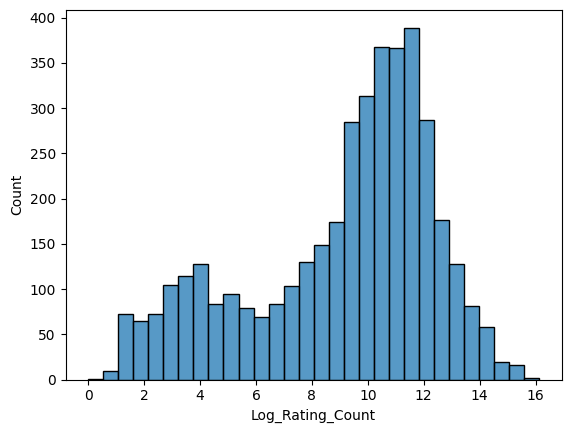

In [25]:
sns.histplot(df["Log_Rating_Count"])

<Axes: xlabel='Review_Count', ylabel='Count'>

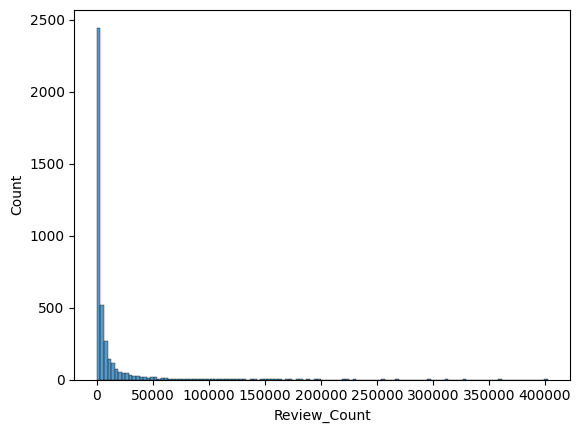

In [26]:
sns.histplot(df["Review_Count"])

In [27]:
df["Popularity_Index"] = (
    np.log1p(df["Rating_Count"]) * df["Rating"]
)

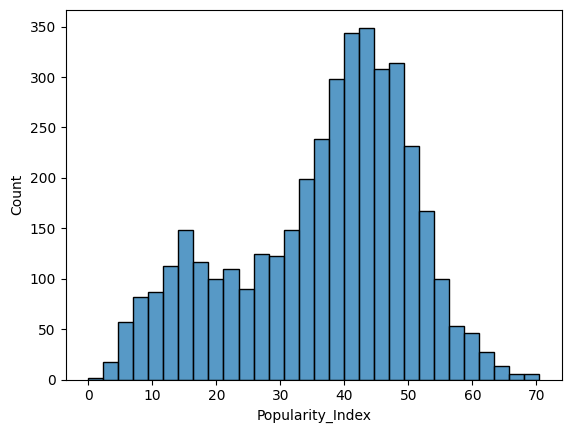

In [28]:
sns.histplot(df["Popularity_Index"])
plt.show()

Target Variable 

`Rating_Count` was selected as the primary target variable because it provides a direct measure of a book’s popularity and reader engagement. To address the highly skewed distribution and reduce the impact of extreme outliers, a logarithmic transformation (`log(Rating_Count + 1)`) was applied before further analysis and modeling.

Univariate Analysis

In [29]:
df["Pub_Year"] = df["Pub_Date"].dt.year

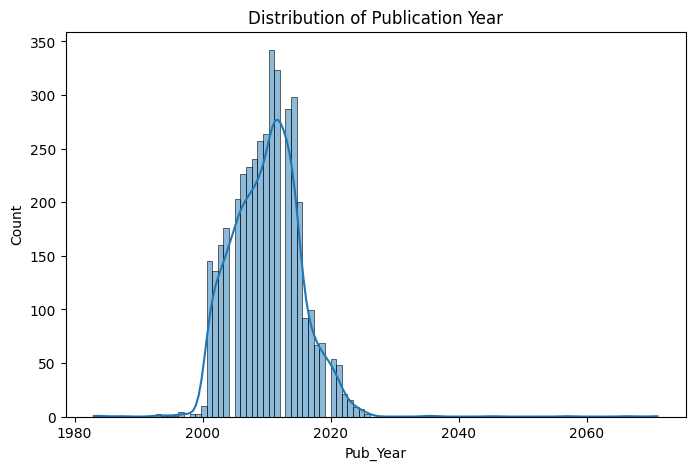

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(df["Pub_Year"], kde=True)

plt.title("Distribution of Publication Year")

plt.show()

In [31]:
df[df["Pub_Year"] > 2026][
    ["Title", "Author", "Pub_Date", "Pub_Year"]
]

,Title,Author,Pub_Date,Pub_Year
2059,And the Hippos Were Boiled in Their Tanks,William S. Burroughs,2045-01-01,2045.0
2060,On the Road: The Original Scroll,Jack Kerouac,2057-09-05,2057.0
2160,The Last Hundred Days,Patrick McGuinness,2066-06-28,2066.0
2719,The Complete Chronicles of Conan,Robert E. Howard,2036-10-01,2036.0
3089,Siete Minutos en Español,Ismael Camacho Arango,2071-01-01,2071.0
3195,Flights from the Lowlands,Florence Morris Rose,2035-01-01,2035.0


- Inspection of publication year anomalies revealed several records containing unrealistic future publication years extending beyond 2026. 
- These entries are likely caused by metadata inconsistencies, scraper parsing issues, or future edition placeholders. 
- To maintain temporal consistency and prevent distortion in trend analysis and modeling, records with invalid future publication years will be filtered from the dataset.

In [32]:
df = df[df["Pub_Year"] <= 2026]

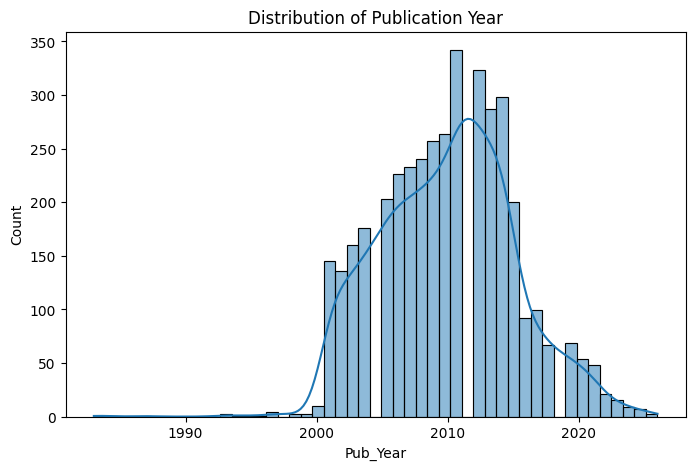

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(df["Pub_Year"], kde=True)

plt.title("Distribution of Publication Year")

plt.show()

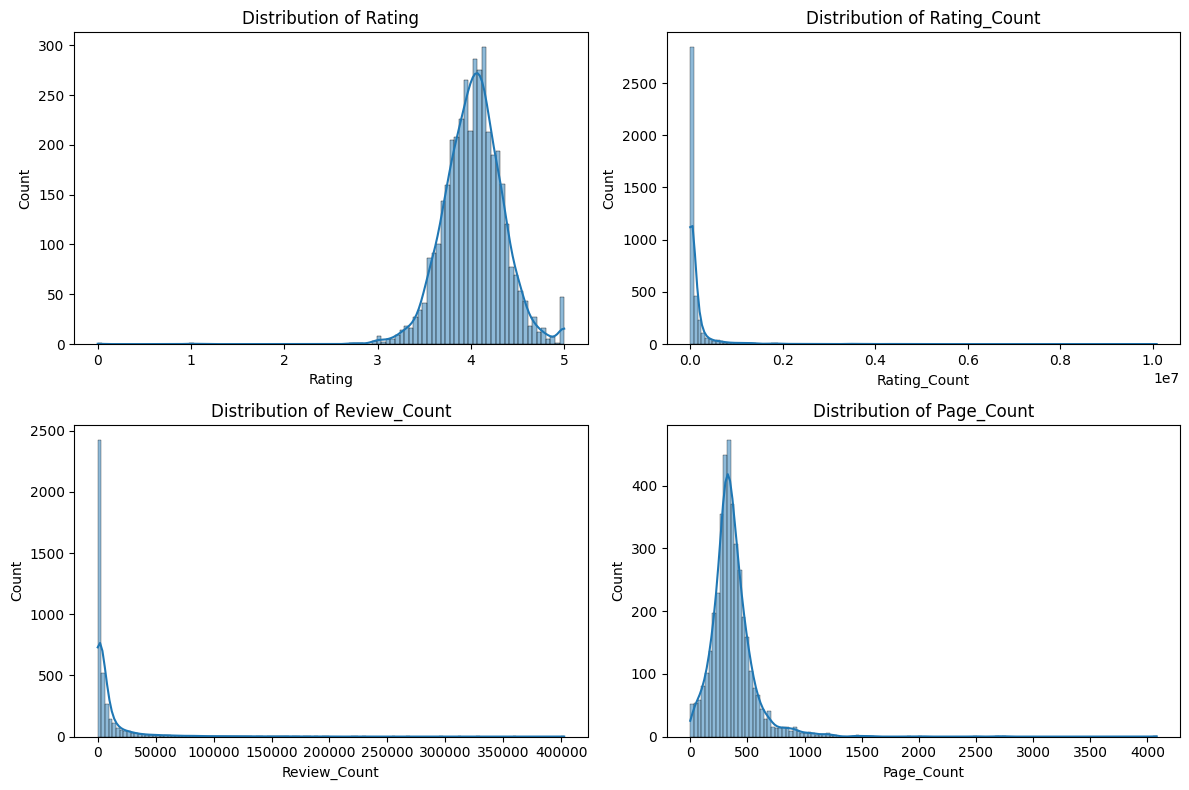

In [34]:
num_cols = [
    "Rating",
    "Rating_Count",
    "Review_Count",
    "Page_Count"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    
    sns.histplot(df[col], kde=True, ax=axes[i])
    
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

- The distribution plots reveal that `Rating_Count` and `Review_Count` are heavily right-skewed with extreme outliers, 
- while `Rating` and `Page_Count` show more centralized distributions with comparatively moderate variation.

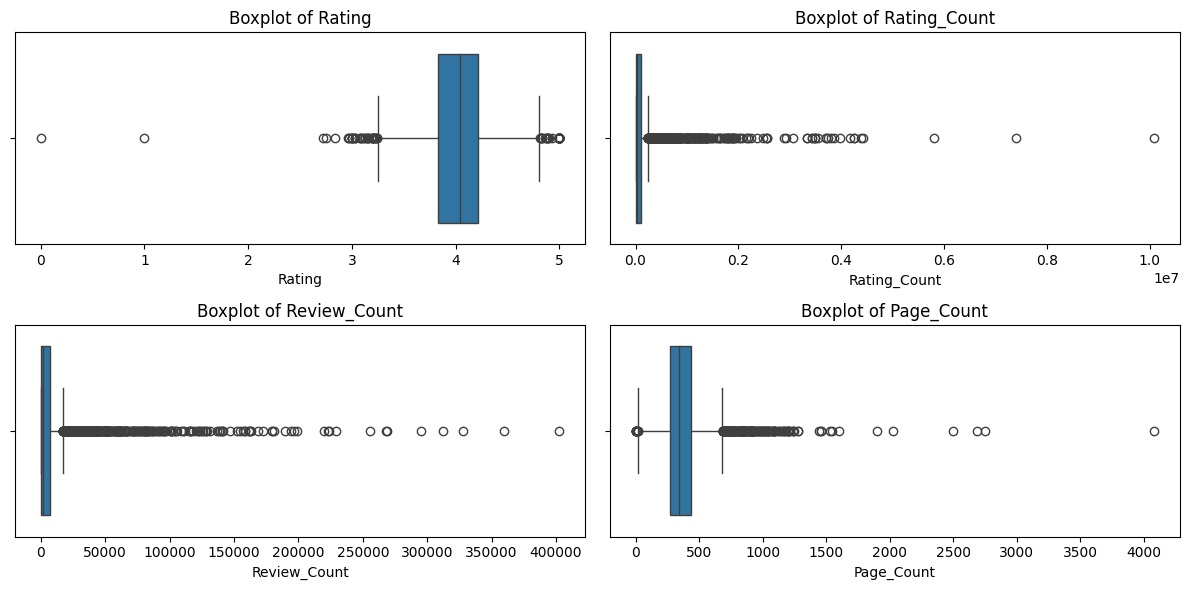

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    
    sns.boxplot(x=df[col], ax=axes[i])
    
    axes[i].set_title(f"Boxplot of {col}")

plt.tight_layout()

plt.show()

- The boxplots highlight the presence of significant outliers in `Rating_Count`, `Review_Count`, and `Page_Count`, 
- indicating highly skewed distributions and the potential need for transformation or outlier handling before model training.

In [36]:
print(df["Genres"].sample(10))


2437    Historical Fiction, Fiction, Fantasy, Witches,...
675     Fiction, Novels, Literature, Contemporary, Lit...
1829    Urban Fantasy, Vampires, Paranormal, Fantasy, ...
476     Fiction, Historical Fiction, Historical, Liter...
2913    Middle Grade, Realistic Fiction, Fiction, Youn...
521     Young Adult, Fantasy, Romance, Paranormal, Aliens
3972            Fantasy, Young Adult, Young Adult Fantasy
2663    Fiction, Book Club, Romance, Mystery, Contempo...
2140    Fantasy, Dystopia, Romance, Young Adult, Enemi...
3928    Young Adult, Romance, Contemporary, Mystery, F...
Name: Genres, dtype: str


In [37]:
from collections import Counter

all_genres = []

for genres in df["Genres"]:
    
    split_genres = genres.split(",")
    
    split_genres = [g.strip() for g in split_genres]
    
    all_genres.extend(split_genres)

genre_counts = Counter(all_genres)

top_genres = pd.DataFrame(
    genre_counts.most_common(15),
    columns=["Genre", "Count"]
)

top_genres

,Genre,Count
0,Fiction,2319
1,Fantasy,1193
2,Romance,820
3,Young Adult,797
4,Historical Fiction,666
5,Nonfiction,628
6,Contemporary,560
7,Book Club,542
8,Mystery,520
9,Audiobook,494


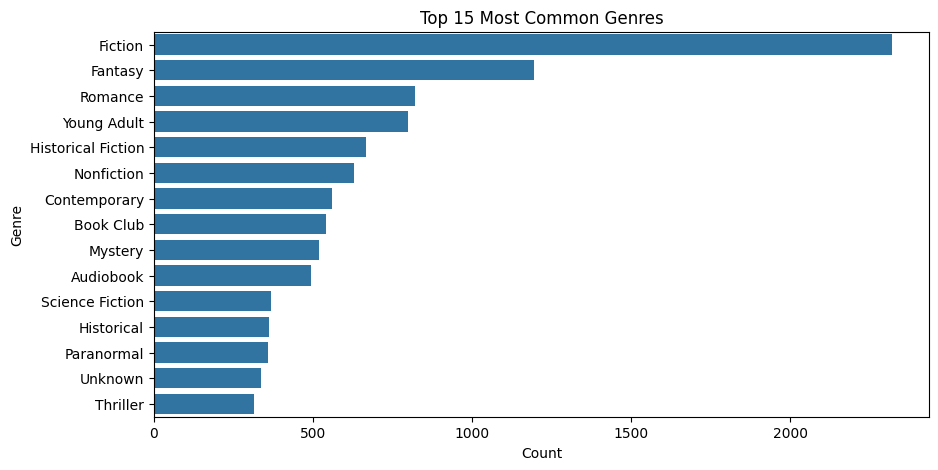

In [38]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=top_genres,
    x="Count",
    y="Genre"
)

plt.title("Top 15 Most Common Genres")

plt.show()

In [39]:
df["Title"].value_counts()

Title
Gone                                                                                              4
Twilight                                                                                          2
Shroud                                                                                            2
Dry                                                                                               2
Bloodlines                                                                                        2
                                                                                                 ..
The Birth of Death                                                                                1
Dom Wars: Round One                                                                               1
Flugfällan                                                                                        1
Peak Performance: Elevate Your Game, Avoid Burnout, and Thrive with the New Science of Success

In [40]:
all_authors = []
for authors in df["Author"]:
    
    split_authors = authors.split(",")
    
    split_authors = [a.strip() for a in split_authors]
    
    all_authors.extend(split_authors)

author_counts = Counter(all_authors)

top_authors = pd.DataFrame(
    author_counts.most_common(15),
    columns=["Author", "Count"]
)

top_authors

,Author,Count
0,Stephen King,22
1,James Patterson,21
2,Rick Riordan,18
3,Richelle Mead,17
4,Kelley Armstrong,17
5,Cassandra Clare,15
6,Terry Pratchett,15
7,Catherine Anderson,14
8,Charlaine Harris,13
9,Scott McElhaney,13


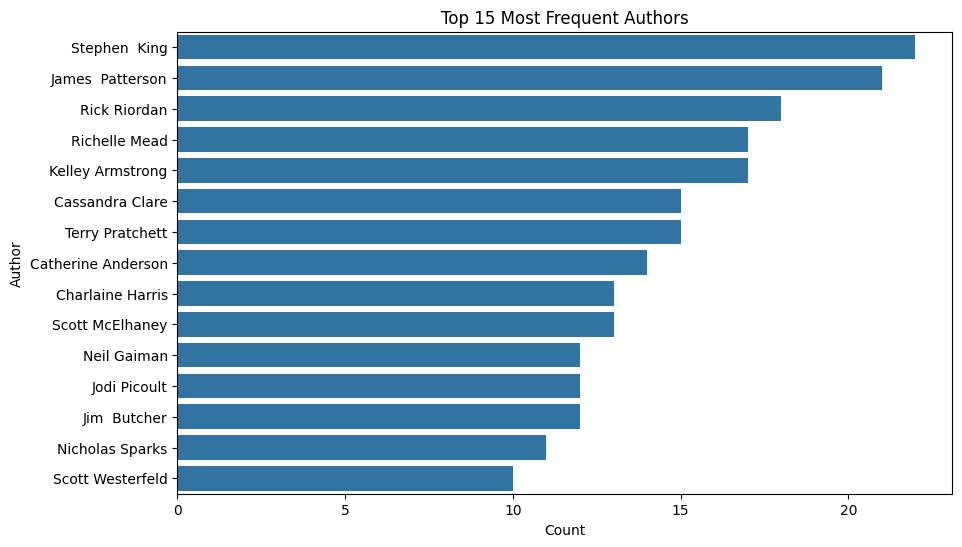

In [41]:
top_authors = df["Author"].value_counts().head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_authors.values,
    y=top_authors.index
)

plt.title("Top 15 Most Frequent Authors")

plt.xlabel("Count")

plt.ylabel("Author")

plt.show()

The author frequency analysis indicates that a small number of authors appear multiple times in the dataset, suggesting some concentration around highly published or widely recognized writers.

In [42]:
df["Description_Word_Count"] = (
    df["Description"]
    .apply(lambda x: len(str(x).split()))
)

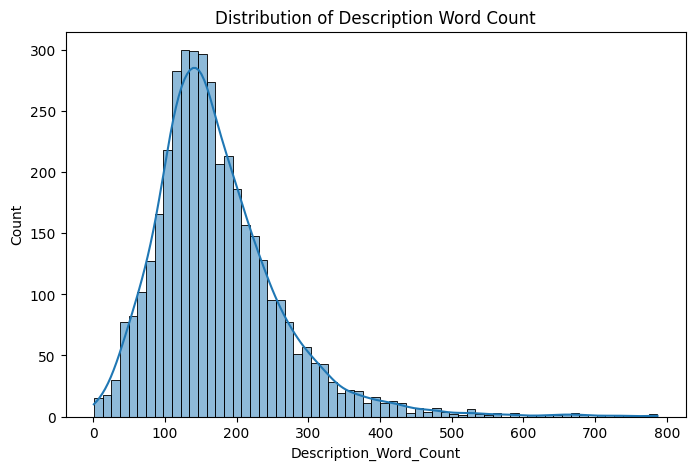

In [43]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Description_Word_Count"],
    kde=True
)

plt.title("Distribution of Description Word Count")

plt.show()

In [44]:
df["Title_Word_Count"] = (
    df["Title"]
    .apply(lambda x: len(str(x).split()))
)

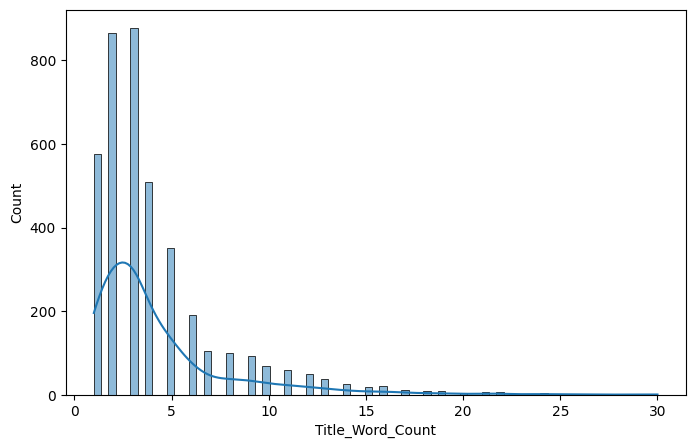

In [45]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Title_Word_Count"],
    kde=True
)


plt.show()

The text-based feature analysis shows that most book descriptions contain a moderate number of words, indicating relatively standardized summary lengths across the dataset. In contrast, title word counts are strongly concentrated around short 2–4 word titles, while a smaller number of books contain unusually long titles, likely due to subtitles or extended metadata formatting.

BIVARIATE ANALYSIS

In [46]:
df[["Review_Count", "Rating_Count"]].corr()

,Review_Count,Rating_Count
Review_Count,1.000000,0.845109
Rating_Count,0.845109,1.000000


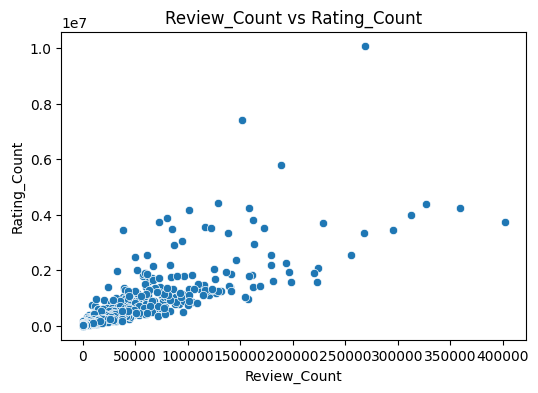

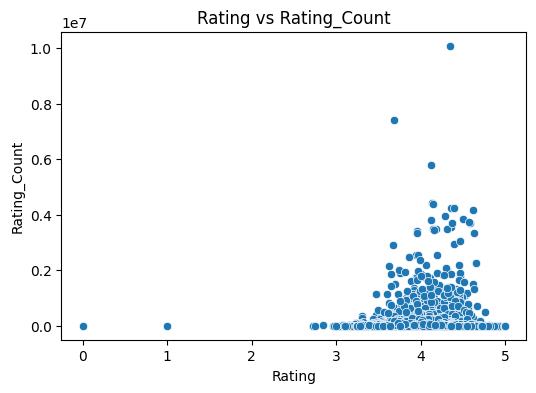

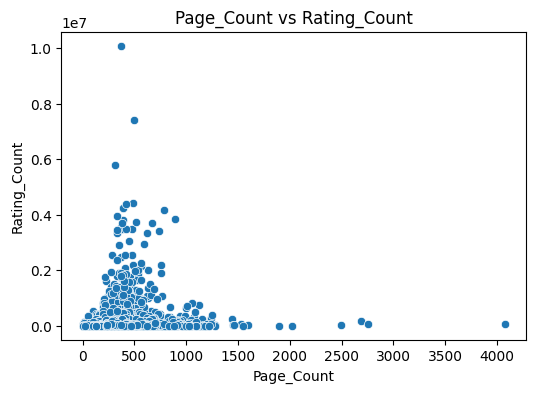

In [47]:
features = ["Review_Count", "Rating", "Page_Count"]

for col in features:
    
    plt.figure(figsize=(6,4))
    
    sns.scatterplot(x=df[col], y=df["Rating_Count"])
    
    plt.title(f"{col} vs Rating_Count")
    
    plt.xlabel(col)
    plt.ylabel("Rating_Count")
    
    plt.show()

In [48]:
df[["Review_Count", "Rating", "Page_Count", "Rating_Count"]].corr()

,Review_Count,Rating,Page_Count,Rating_Count
Review_Count,1.000000,0.096220,0.085904,0.845109
Rating,0.096220,1.000000,0.128744,0.082150
Page_Count,0.085904,0.128744,1.000000,0.097479
Rating_Count,0.845109,0.082150,0.097479,1.000000


In [49]:
genre_popularity = df.explode("Genres")

genre_popularity.groupby("Genres")["Rating_Count"].mean().sort_values(ascending=False).head(15)

Genres
Fantasy, Young Adult, Romance, Fiction, Vampires                    7407971.0
Young Adult, Dystopia, Fiction, Fantasy, Science Fiction            4819908.0
Fiction, Romance, Historical Fiction, LGBT, Book Club               4246589.0
Thriller, Romance, Fiction, Mystery, Colleen Hoover                 3970608.0
Fantasy, Fiction, Young Adult, Harry Potter, Magic                  3913670.0
Fantasy, Romance, Romantasy, Young Adult, Fiction                   3864083.0
Fantasy, Romance, Romantasy, Dragons, Fiction                       3743208.0
Fiction, Book Club, Historical Fiction, Mystery, Audiobook          3708658.0
Fiction, Historical Fiction, Classics, Contemporary, Book Club      3548170.0
Young Adult, Romance, Fiction, Contemporary, Realistic Fiction      3534656.5
Thriller, Mystery, Fiction, Book Club, Mystery Thriller             3431028.0
Fiction, Historical Fiction, Book Club, Historical, Classics        3055916.0
Historical Fiction, Fiction, Young Adult, Classics, Histo

In [51]:
df_genre = df.copy()

df_genre["Genres"] = df_genre["Genres"].astype(str).str.split(",")

df_genre = df_genre.explode("Genres")

df_genre["Genres"] = df_genre["Genres"].str.strip()

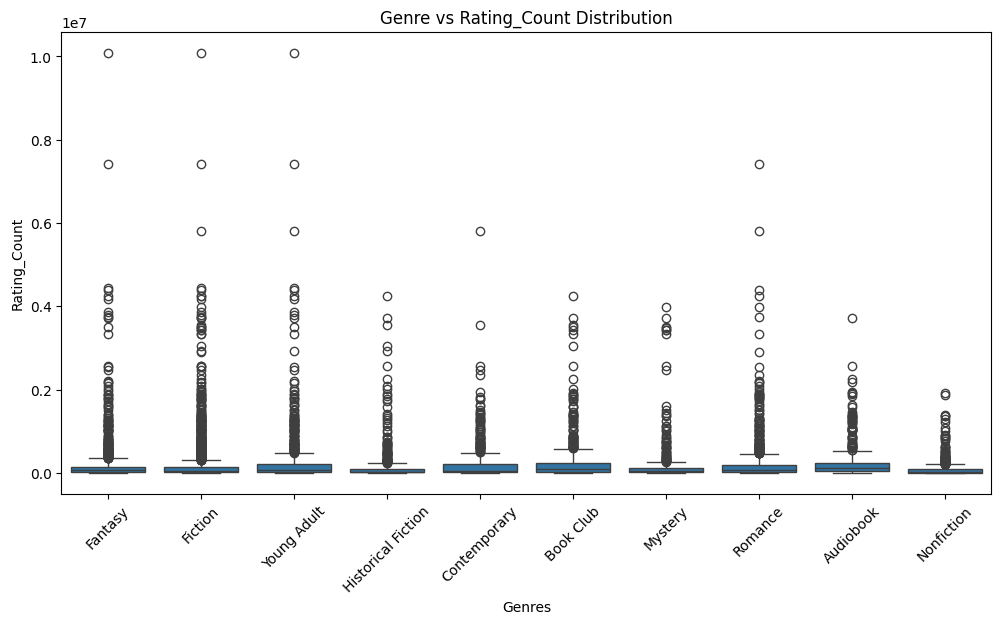

In [52]:
top_genres = df_genre["Genres"].value_counts().head(10).index

df_top_genres = df_genre[df_genre["Genres"].isin(top_genres)]

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_top_genres,
    x="Genres",
    y="Rating_Count"
)

plt.xticks(rotation=45)

plt.title("Genre vs Rating_Count Distribution")

plt.show()

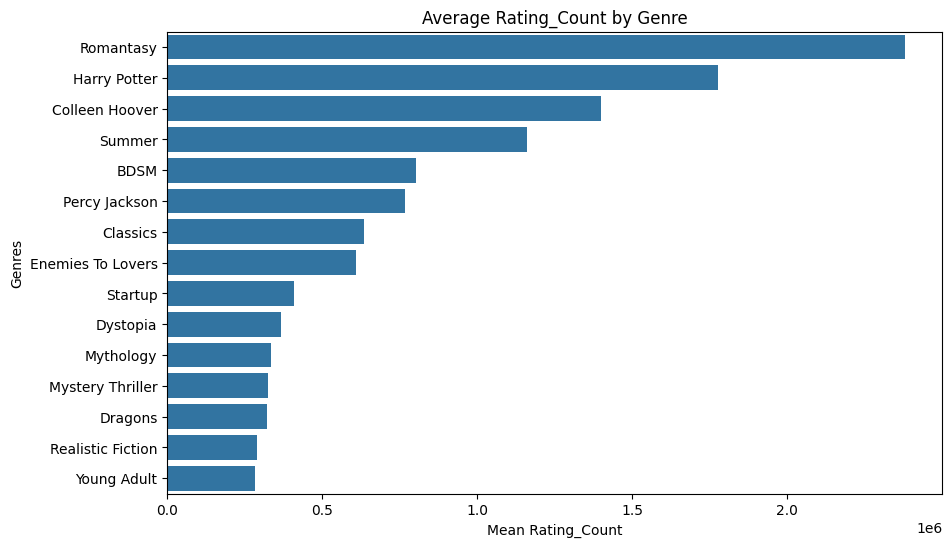

In [53]:
genre_mean = df_genre.groupby("Genres")["Rating_Count"].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))

sns.barplot(x=genre_mean.values, y=genre_mean.index)

plt.title("Average Rating_Count by Genre")

plt.xlabel("Mean Rating_Count")

plt.show()

The Genres column is not purely categorical in a strict sense. It contains a mixture of true literary genres, sub-genres, series names, author-related tags, and reading-format labels (e.g., Audiobook, Book Club), indicating noisy metadata from the data source.